### creating object with sync video and parse telemetry

In [47]:
from utilities.TelementryVideoSync import TelemetryVideoSync
from utilities.PX4CSVPlotter import PX4CSVPlotter
import os
from collections import namedtuple
import numpy as np
import pickle

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
DATA_DIR = "data/2/"
pickle_path = os.path.join(DATA_DIR, "data.pkl")
video_path = os.path.join(DATA_DIR, "straight.mkv")
output_path = os.path.join(DATA_DIR, "output.mp4")
ulog_path = os.path.join(DATA_DIR, "ulg.ulg")
csv_path = os.path.join(DATA_DIR, "csv")
Data = namedtuple("Data", ["frames", "gps_time", "gps_alt", "yaw", "pitch", "roll"])

TELEMETRY_START_IDX = 3814
TELEMETRY_END_IDX = 13779

VIDEO_START_MESS = 15.233333333333333
VIDEO_END_MESS = 55.833333333333336

SAVE_EVERY_N = 1
PLOT_EVERY_N = 10




In [48]:


# --------------------------------------------------
# CREATE OBJECT
# --------------------------------------------------

sync = TelemetryVideoSync(
    telemetry_start_idx=TELEMETRY_START_IDX,
    telemetry_end_idx=TELEMETRY_END_IDX,
    video_start_time=VIDEO_START_MESS,
    video_end_time=VIDEO_END_MESS,
    video_path=video_path,
    ulog_path=ulog_path,
    csv_path=csv_path,
    save_every_n=SAVE_EVERY_N,
    plot_every_n=PLOT_EVERY_N,
)
# --------------------------------------------------
# PIPELINE
# --------------------------------------------------
# %matplotlib qt
# sync.debug_select_window_all()


In [ ]:
# sync.debug_detect_motion_video()
# 1. Convert ULOG → CSV (run once)
sync.read_telemetry()


# 2. Load telemetry, cut, resample, load video frames
sync.analyze_telemetry()

# 3. Play synchronized telemetry video
sync.play_telemetry_video()

Video FPS: 30.0


KeyboardInterrupt: 

In [ ]:
print("frames shape:", sync.frames.shape)
print("gps_time shape:", sync.gps_time.shape)
print("gps_alt shape:", sync.gps_alt.shape)
print("yaw shape:", sync.yaw.shape)
print("pitch shape:", sync.pitch.shape)
print("roll shape:", sync.roll.shape)

In [ ]:



step = 1

data = Data(
    frames=np.array(sync.frames)[::step],
    gps_time=np.array(sync.gps_time)[::step],
    gps_alt=np.array(sync.gps_alt)[::step],
    yaw=np.array(sync.yaw)[::step],
    pitch=np.array(sync.pitch)[::step],
    roll=np.array(sync.roll)[::step],
)
del sync

In [ ]:
with open(pickle_path, "wb") as f:
    pickle.dump(data, f)


In [ ]:

del data

import gc
gc.collect()


## Analyzing part

In [56]:
from utilities.TelementryVideoSync import TelemetryVideoSync
from utilities.PX4CSVPlotter import PX4CSVPlotter
import os
from collections import namedtuple
import numpy as np
import pickle






In [67]:
import pickle


with open(pickle_path, "rb") as f:
    data = pickle.load(f)


In [68]:
every_n_row = 1

data = Data(*(arr[::every_n_row] for arr in data))

In [69]:
threshold = 5
exclude_first = 250
exclude_last = 400
mask = (np.abs(data.pitch) <= threshold) & (np.abs(data.roll) <= threshold)


mask = (np.abs(data.pitch) <= threshold) & (np.abs(data.roll) <= threshold)
mask[:exclude_first] = False
mask[-exclude_last:] = False

data = Data(
    frames=data.frames[mask],
    gps_time=data.gps_time[mask],
    gps_alt=data.gps_alt[mask],
    yaw=data.yaw[mask],
    pitch=data.pitch[mask],
    roll=data.roll[mask],
)



In [ ]:
# import cv2
# import numpy as np

# frames = data.frames
# fps = 30  # set your desired fps
# delay = int(1000 / fps)

# for i, frame in enumerate(frames):
#     if frame.shape[2] == 3:
#         frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
#     else:
#         frame_bgr = frame

#     # add frame index text
#     cv2.putText(
#         frame_bgr,
#         f"Frame: {i}",
#         (20, 40),
#         cv2.FONT_HERSHEY_SIMPLEX,
#         1,
#         (0, 255, 0),
#         2
#     )

#     cv2.imshow("Filtered Frames", frame_bgr)

#     if cv2.waitKey(delay) == 27:  # press ESC to exit
#         break

# cv2.destroyAllWindows()


In [71]:
# import cv2
# yaw = (data.yaw + 360) % 360
#
#
# rotated_frames = []
# for img, y in zip(data.frames, yaw):
#     M = cv2.getRotationMatrix2D((img.shape[1]/2, img.shape[0]/2), -y, 1)
#     rotated = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))
#     rotated_frames.append(rotated)
#
# data = Data(
#     frames=np.array(rotated_frames),
#     gps_time=data.gps_time,
#     gps_alt=data.gps_alt,
#     yaw=yaw,
#     pitch=data.pitch,
#     roll=data.roll,
# )


In [72]:
# import matplotlib.pyplot as plt
#
# SHOW_EVERY_N = 50
#
# n = min(
#     len(data.frames),
#     len(data.gps_time),
#     len(data.gps_alt),
#     len(data.yaw),
#     len(data.pitch),
#     len(data.roll),
# )
#
# for i in range(0, n, SHOW_EVERY_N):
#     fig, axes = plt.subplots(
#         2, 1,
#         figsize=(10, 7),
#         gridspec_kw={"height_ratios": [3, 1]}
#     )
#
#     # ---------- IMAGE ----------
#     axes[0].imshow(data.frames[i])
#     axes[0].set_title(f"Frame {i}")
#     axes[0].axis("off")
#
#     # ---------- TELEMETRY ----------
#     text = (
#         f"Time:  {data.gps_time[i]:.2f} s\n"
#         f"Alt:   {data.gps_alt[i]:.2f} m\n"
#         f"Yaw:   {data.yaw[i]:.2f} deg\n"
#         f"Pitch: {data.pitch[i]:.2f} deg\n"
#         f"Roll:  {data.roll[i]:.2f} deg"
#     )
#
#     axes[1].text(
#         0.05, 0.5,
#         text,
#         fontsize=12,
#         va="center",
#         ha="left"
#     )
#     axes[1].axis("off")
#
#     plt.tight_layout()
#     plt.show()


In [108]:
import numpy as np
import cv2

frames = data.frames

feature_params = dict(
    maxCorners=800,
    qualityLevel=0.03,
    minDistance=5,
    blockSize=5
)

lk_params = dict(
    winSize=(21, 21),      # bigger window for faster motion
    maxLevel=3,            # deeper pyramid for large movement
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        30,
        0.01
    )
)


dx_list = []
dy_list = []

old_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

for i in range(1, len(frames)):
    frame_gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)

    # If no points to track, re-detect
    if p0 is None or len(p0) == 0:
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        if p0 is None:
            continue

    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # If tracking failed completely, re-detect points and skip
    if p1 is None or st is None:
        old_gray = frame_gray
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        continue

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    if len(good_new) == 0:
        old_gray = frame_gray
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        continue

    flow = good_new - good_old

    dx = np.median(flow[:, 0])
    dy = np.median(flow[:, 1])

    dx_list.append(dx)
    dy_list.append(dy)

    old_gray = frame_gray
    p0 = good_new.reshape(-1, 1, 2)

print("Done!")


Done!


In [109]:
import numpy as np

def remove_spikes_mad(x, thresh=30):
    x = np.asarray(x)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        return x
    z = 0.6745 * (x - med) / mad
    x_clean = x.copy()
    x_clean[np.abs(z) > thresh] = med
    return x_clean

# dx_list = remove_spikes_mad(dx_list)
# dy_list = remove_spikes_mad(dy_list)


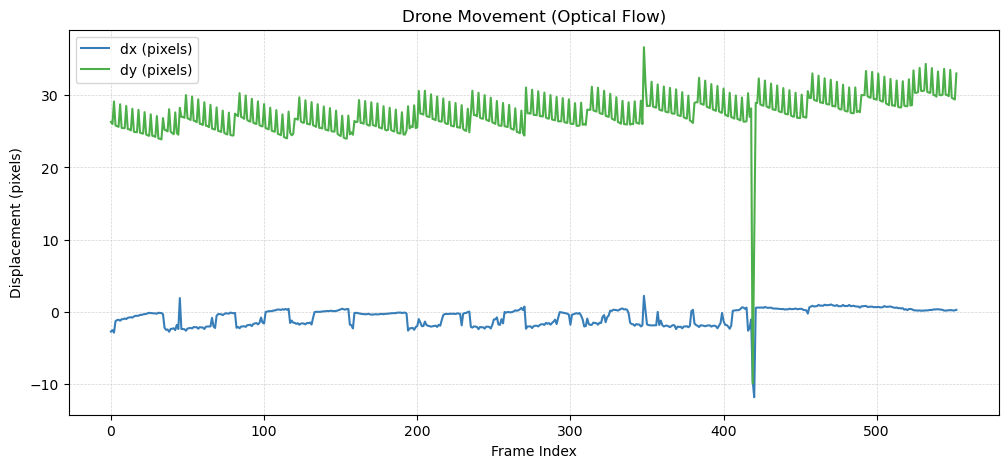

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(dx_list, label="dx (pixels)")
plt.plot(dy_list, label="dy (pixels)")
plt.title("Drone Movement (Optical Flow)")
plt.xlabel("Frame Index")
plt.ylabel("Displacement (pixels)")
plt.legend()
plt.grid(True)
plt.show()


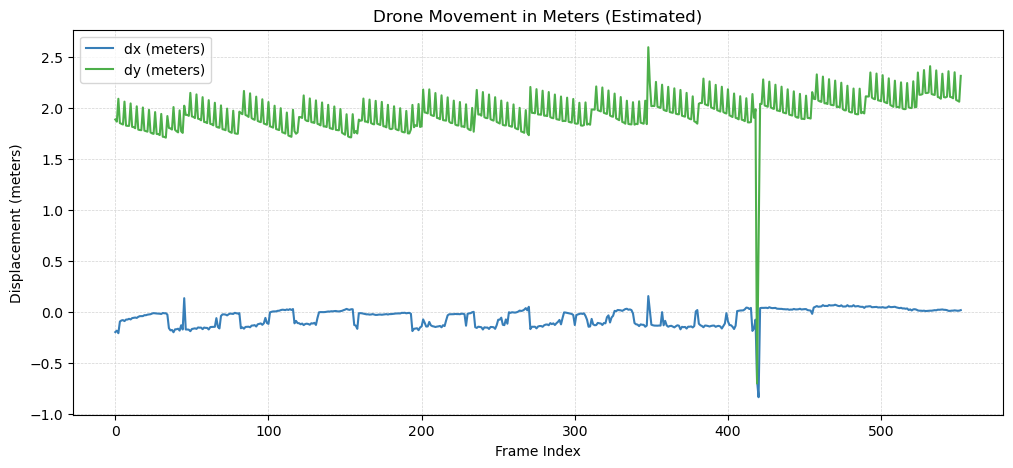

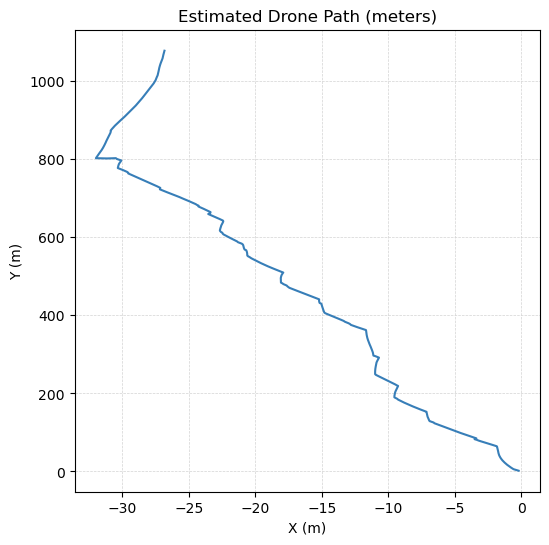

In [111]:
import numpy as np
import matplotlib.pyplot as plt

# ---- camera parameter (change if you know it) ----
FOV_VERTICAL_DEG = 80

# ---- compute meters per pixel using altitude for each frame ----
fov_rad = np.deg2rad(FOV_VERTICAL_DEG)

img_h = data.frames[0].shape[0]

# meters per pixel per frame (depends on altitude)
meters_per_pixel = 2 * data.gps_alt[:len(dx_list)] * np.tan(fov_rad / 2) / img_h



dx_m = np.array(dx_list) * meters_per_pixel
dy_m = np.array(dy_list) * meters_per_pixel

# ---- plot in meters ----
plt.figure(figsize=(12, 5))
plt.plot(dx_m, label="dx (meters)")
plt.plot(dy_m, label="dy (meters)")
plt.title("Drone Movement in Meters (Estimated)")
plt.xlabel("Frame Index")
plt.ylabel("Displacement (meters)")
plt.legend()
plt.grid(True)
plt.show()

# ---- plot trajectory ----
x = np.cumsum(dx_m)
y = np.cumsum(dy_m)

plt.figure(figsize=(6, 6))
plt.plot(x, y)
plt.title("Estimated Drone Path (meters)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.show()


# pamietać że to jest gps nie obcinany gdzie wielkości się nie zgadzają


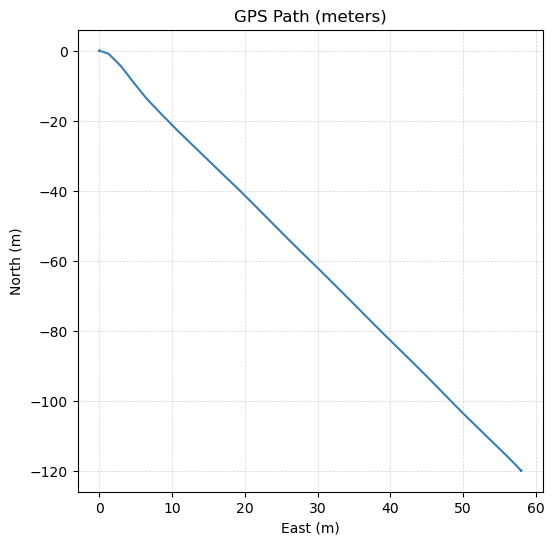

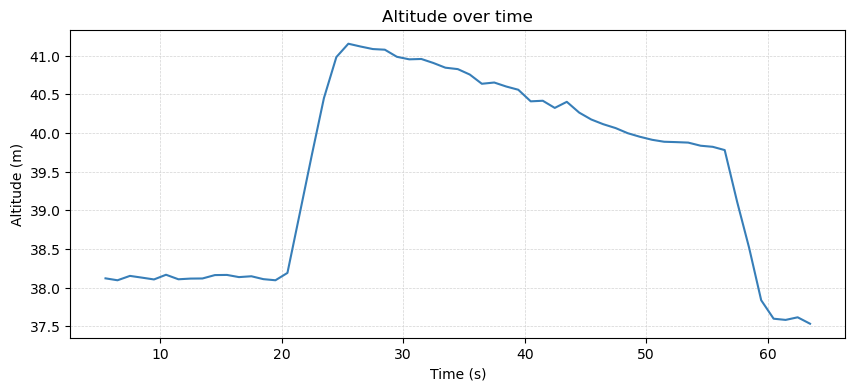

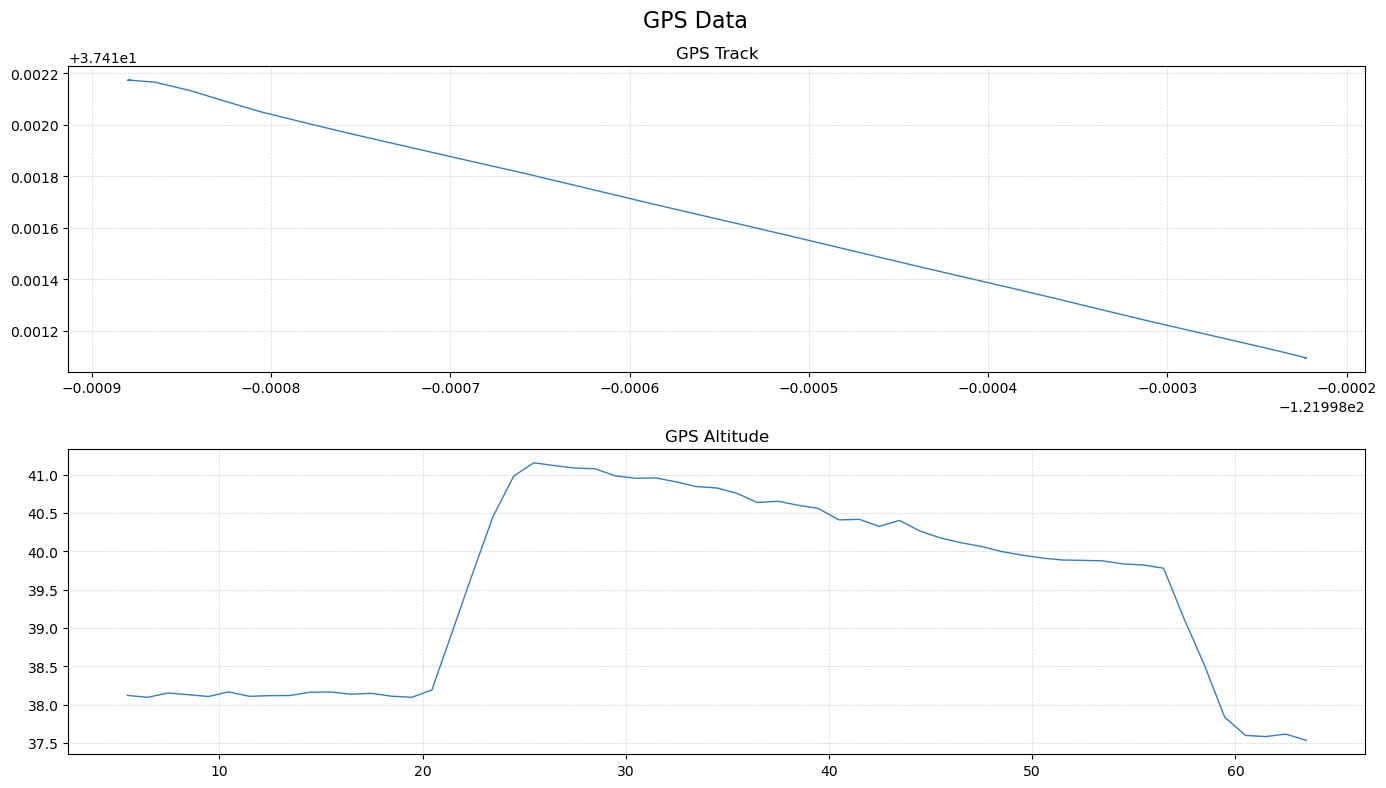

(array([ 5.48 ,  6.468,  7.492,  8.484,  9.472, 10.464, 11.484, 12.476,
        13.464, 14.488, 15.48 , 16.468, 17.492, 18.48 , 19.472, 20.46 ,
        21.484, 22.476, 23.464, 24.488, 25.476, 26.468, 27.492, 28.48 ,
        29.472, 30.492, 31.484, 32.472, 33.464, 34.488, 35.476, 36.468,
        37.488, 38.48 , 39.468, 40.492, 41.484, 42.472, 43.464, 44.484,
        45.476, 46.464, 47.488, 48.48 , 49.468, 50.492, 51.48 , 52.472,
        53.46 , 54.484, 55.476, 56.464, 57.488, 58.476, 59.468, 60.492,
        61.48 , 62.472, 63.492]),
 array([-121.99887888, -121.99887883, -121.99887856, -121.99887869,
        -121.99887872, -121.99887904, -121.9988788 , -121.99887896,
        -121.99887851, -121.99887856, -121.99887839, -121.99887859,
        -121.99887877, -121.99887875, -121.99887885, -121.99887878,
        -121.99888009, -121.99887935, -121.99887857, -121.99886457,
        -121.99884489, -121.99882615, -121.99880594, -121.9987828 ,
        -121.99875903, -121.99873345, -121.99870815, -

In [112]:
from utilities.PX4CSVPlotter import PX4CSVPlotter

# Wczytaj i wyświetl wszystkie wykresy
plotter = PX4CSVPlotter(csv_path)
plotter.plot_gps()